# StatsBomb Shotmap Tutorial

This notebook walks through a clean end-to-end workflow:
1. load the Bundesliga 2023/24 matches,
2. isolate Bayer Leverkusen fixtures,
3. collect the match events,
4. filter to shots,
5. prepare the shot coordinates, and
6. render a StatsBomb-style shotmap.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, Arc, Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from statsbombpy import sb
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from mplsoccer import VerticalPitch

#display all columns in the dataframe
pd.set_option('display.max_columns', None)

## 1. Load the competition and team matches

We start by loading the Bundesliga 2023/24 match list and then keep only the matches involving Bayer Leverkusen. You can use any data for this part!!

In [2]:
competition_id = 9
season_id = 281
team_name = "Bayer Leverkusen"
competition_name = "Bundesliga 2023/24"

matches = sb.matches(competition_id=competition_id, season_id=season_id)
team_matches = matches[(matches["home_team"] == team_name) | (matches["away_team"] == team_name)].copy()

print(f"Found {len(matches)} matches in {competition_name}")
print(f"Found {len(team_matches)} Bayer Leverkusen matches")
team_matches[["match_id", "home_team", "away_team", "match_date"]].head(10)

Found 34 matches in Bundesliga 2023/24
Found 34 Bayer Leverkusen matches


,match_id,home_team,away_team,match_date
0,3895302,Bayer Leverkusen,Werder Bremen,2024-04-14
1,3895292,Union Berlin,Bayer Leverkusen,2024-04-06
2,3895333,Eintracht Frankfurt,Bayer Leverkusen,2024-05-05
3,3895340,Bochum,Bayer Leverkusen,2024-05-12
4,3895348,Bayer Leverkusen,Augsburg,2024-05-18
5,3895286,Bayer Leverkusen,Hoffenheim,2024-03-30
6,3895220,Darmstadt 98,Bayer Leverkusen,2024-02-03
7,3895250,Bayer Leverkusen,FSV Mainz 05,2024-02-23
8,3895266,Bayer Leverkusen,Wolfsburg,2024-03-10
9,3895275,Freiburg,Bayer Leverkusen,2024-03-17


## 2. Pull the event data for each match

The next step is to fetch the event feed for every Bayer Leverkusen match we kept in the previous cell.

In [3]:
all_events = []
for match_id in team_matches["match_id"]:
    try:
        match_events = sb.events(match_id=match_id)
        all_events.append(match_events)
        print(f"Fetched match {match_id}")
    except Exception as exc:
        print(f"Error fetching match {match_id}: {exc}")

events = pd.concat(all_events, ignore_index=True)
events = events[events["team"] == team_name].copy()
print(f"Total Bayer Leverkusen events: {len(events)}")
events.head()

Fetched match 3895302
Fetched match 3895292
Fetched match 3895333
Fetched match 3895340
Fetched match 3895348
Fetched match 3895286
Fetched match 3895220
Fetched match 3895250
Fetched match 3895266
Fetched match 3895275
Fetched match 3895180
Fetched match 3895134
Fetched match 3895121
Fetched match 3895107
Fetched match 3895074
Fetched match 3895139
Fetched match 3895086
Fetched match 3895320
Fetched match 3895309
Fetched match 3895258
Fetched match 3895244
Fetched match 3895232
Fetched match 3895210
Fetched match 3895202
Fetched match 3895194
Fetched match 3895182
Fetched match 3895167
Fetched match 3895158
Fetched match 3895153
Fetched match 3895113
Fetched match 3895095
Fetched match 3895067
Fetched match 3895060
Fetched match 3895052
Total Bayer Leverkusen events: 81440


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,ball_recovery_offensive,block_offensive,dribble_overrun,foul_committed_type,miscontrol_aerial_won,foul_committed_offensive,shot_deflected,pass_miscommunication,pass_no_touch,goalkeeper_punched_out,pass_straight,shot_open_goal,dribble_no_touch,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_shot_saved_to_post,shot_saved_to_post,clearance_other,goalkeeper_success_out,goalkeeper_success_in_play
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,794ec549-5288-4d1a-93e8-0fc6d3968784,1,NaN,NaN,NaN,3895302,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Bayer Leverkusen,904,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 3421, 'lineup': [{'player': {'id...",Bayer Leverkusen,904,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1f956a2b-ece0-475b-8802-e82ed922c307,3,NaN,NaN,NaN,3895302,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Bayer Leverkusen,904,[79b90fbb-2cfd-419b-90f4-f0e5980c47d3],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d5386215-ef71-4cb0-a46b-087754baba4e,2344,NaN,NaN,NaN,3895302,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,69,Bayer Leverkusen,904,[d1909cc4-05fd-4f56-aaba-6b55a729f6f4],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,2.232857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b8ea5d17-518b-4f87-86cf-557d57345a23,34,NaN,NaN,"[33.3, 43.2]",3895302,0,NaN,NaN,NaN,-2.779292,NaN,Right Foot,NaN,NaN,NaN,"[8.5, 33.8]",NaN,Ground Pass,NaN,26.521688,NaN,NaN,Lukáš Hrádecký,8667.0,NaN,NaN,NaN,NaN,Interception,1,Regular Play,Nathan Tella,41411.0,Right Wing Back,3,Bayer Leverkusen,904,"[76ebbb25-3467-413b-8497-f3e38f998e57, cd206d6...",19,

## 3. Filter the shot data

Now that the event table is loaded, keep only Bayer Leverkusen shots and inspect the key columns we need for the shotmap.

In [4]:
shots = events[events["type"] == "Shot"].copy()
print(f"Total Bayer Leverkusen shots: {len(shots)}")
print(shots[["player", "shot_outcome", "shot_statsbomb_xg", "shot_body_part"]].head())

Total Bayer Leverkusen shots: 623
                           player shot_outcome  shot_statsbomb_xg  \
4094  Piero Martín Hincapié Reyna        Saved           0.143381   
4096                 Jonathan Tah      Blocked           0.052781   
4097                 Granit Xhaka      Blocked           0.021272   
4098                 Jonathan Tah      Wayward           0.029664   
4100         Victor Okoh Boniface         Goal           0.783500   

     shot_body_part  
4094      Left Foot  
4096           Head  
4097      Left Foot  
4098           Head  
4100     Right Foot  


In [5]:
shots.columns.tolist()

['50_50',
 'bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'block_save_block',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_penalty',
 'foul_won_advantage',
 'foul_won_defensive',
 'foul_won_penalty',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_insw

In [6]:
shots = shots.copy()
shots["X"] = shots["location"].apply(lambda x: x[0])
shots["Y"] = shots["location"].apply(lambda x: x[1])

## 4. Set up the visual style and font

This notebook keeps the dark, branded shotmap style from the original version, but the walkthrough is now organized as a tutorial.

In [7]:
background_color = '#0C0D0E'

import matplotlib.font_manager as font_manager
import urllib.request
import os

font_url = 'https://raw.githubusercontent.com/google/fonts/main/ofl/bebasneue/BebasNeue-Regular.ttf'
font_filename = 'BebasNeue-Regular.ttf'

if not os.path.exists(font_filename):
    try:
        urllib.request.urlretrieve(font_url, font_filename)
        print(f"Font downloaded successfully: {font_filename}")
    except Exception as e:
        print(f"Warning: Could not download font ({e}). Using default font instead.")
        font_filename = None

if font_filename and os.path.exists(font_filename):
    font_props = font_manager.FontProperties(fname=font_filename)
else:
    font_props = font_manager.FontProperties()

## 5. Define the shotmap drawing helpers

The next cell contains the reusable drawing functions for shot outcomes, legends, and the pitch layout.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Arc


xg_colors = [
        "#082a6b",
        "#2f4f8f",
        "#5a8ec1",
        "#83b3c8",
        "#bae4c5",
        "#f5e57f",
        "#f3d946",
        "#f0b246",
        "#e78b35",
        "#d35f29",
        "#c72614",
        "#880606"
    ]

def xg_color(xg):
    xg = max(0.0, min(float(xg), 0.80))
    
    t = (xg / 0.80) ** 0.5
    bin_idx = min(int(t * len(xg_colors)), len(xg_colors) - 1)
    
    return xg_colors[bin_idx]


def _prepare_shots(shots_df, events_df=None):
    df = shots_df.copy()
    df["is_penalty"] = df["shot_type"].fillna("").astype(str).str.contains("Penalty", case=False)
    df["is_set_piece"] = (
        df["shot_type"].fillna("").astype(str).str.contains("Penalty|Free Kick", case=False, regex=True)
        | df["play_pattern"].fillna("").astype(str).str.contains("Set Piece|Corner", case=False, regex=True)
    )
    df["is_cross_assist"] = False
    df["is_throughball_assist"] = False

    if events_df is not None and "shot_key_pass_id" in df.columns and "id" in events_df.columns:
        pass_cols = ["id", "pass_cross", "pass_through_ball"]
        pass_map = events_df[pass_cols].copy().rename(columns={
            "id": "shot_key_pass_id",
            "pass_cross": "kp_pass_cross",
            "pass_through_ball": "kp_pass_through_ball",
        })
        df = df.merge(pass_map, on="shot_key_pass_id", how="left")
        df["is_cross_assist"] = df["kp_pass_cross"].fillna(False)
        df["is_throughball_assist"] = df["kp_pass_through_ball"].fillna(False)

    df["is_dribble_shot"] = (
        df["shot_key_pass_id"].isna()
        & df["shot_type"].fillna("").astype(str).str.contains("Open Play", case=False)
        & df["play_pattern"].fillna("").astype(str).str.contains("Regular Play", case=False)
    )
    return df


def classify_shot(row, color_fn=xg_color):
    outcome = str(row.get("shot_outcome", "") or "").lower()
    bodypart = str(row.get("shot_body_part", "") or "").lower()
    xg = float(row.get("shot_statsbomb_xg", 0) or 0)

    if row.get("is_penalty", False) or str(row.get("shot_type", "") or "").lower() == "free kick":
        marker = "s"
    elif row.get("is_throughball_assist", False):
        marker = "^"
    elif row.get("is_dribble_shot", False):
        marker = "d"
    elif "head" in bodypart:
        marker = "o"
    else:
        marker = "h"

    if outcome == "goal":
        out = "goal"
    elif "saved" in outcome or "wayward" in outcome:
        out = "saved"
    elif "blocked" in outcome:
        out = "blocked"
    elif "own goal" in outcome:
        out = "own_goal"
    else:
        out = "off_target"

    color = color_fn(xg)
    size = 220 if marker == "d" else 300
    return out, marker, color, size


def _sc(ax, x, y, marker, fc, s, zorder, alpha=1.0, trans=False):
    kw = dict(
        facecolors=[mcolors.to_rgba(fc, alpha) if fc != "none" else "none"],
        edgecolors="none",
        linewidths=0,
        zorder=zorder,
        clip_on=(not trans),
    )
    if trans:
        kw["transform"] = ax.transAxes
    ax.scatter(x, y, s=s, marker=marker, **kw)


def _sc_edge(ax, x, y, marker, fc, ec, lw, s, zorder, alpha=1.0, trans=False):
    kw = dict(
        facecolors=[mcolors.to_rgba(fc, alpha)] if fc != "none" else "none",
        edgecolors=[ec],
        linewidths=lw,
        zorder=zorder,
        clip_on=(not trans),
    )
    if trans:
        kw["transform"] = ax.transAxes
    ax.scatter(x, y, s=s, marker=marker, **kw)


def _draw_goal(ax, x, y, marker, color, s, zorder, alpha=1.0, trans=False):
    _sc(ax, x, y, marker, "#111111", s * 1.7, zorder, 1.0, trans)
    _sc(ax, x, y, marker, "#ffffff", s * 1.35, zorder + 3, 1.0, trans)
    _sc(ax, x, y, marker, color, s, zorder + 6, alpha, trans)


def _draw_saved(ax, x, y, marker, color, s, zorder, alpha=1.0, trans=False):
    _sc_edge(ax, x, y, marker, color, "#111111", 1.6, s, zorder + 3, alpha, trans)


def _draw_off_target(ax, x, y, marker, color, s, zorder, alpha=1.0, trans=False):
    _sc_edge(ax, x, y, marker, color, "#c5c5c5", 1.4, s, zorder + 3, alpha, trans)


def _draw_blocked(ax, x, y, marker, s, zorder, alpha=1.0, trans=False):
    _sc_edge(ax, x, y, marker, "#cccccc", "#888888", 1.4, s, zorder + 3, alpha, trans)


def _draw_own_goal(ax, x, y, marker, s, zorder, alpha=1.0, trans=False):
    _sc(ax, x, y, marker, "#111111", s * 1.7, zorder, 1.0, trans)
    _sc(ax, x, y, marker, "#ffffff", s * 1.35, zorder + 3, 1.0, trans)
    _sc(ax, x, y, marker, "#111111", s, zorder + 6, alpha, trans)


def _draw_outcome(ax, x, y, marker, out, color, s, base_zorder, alpha=1.0, trans=False):
    if out == "goal":
        _draw_goal(ax, x, y, marker, color, s, base_zorder, alpha, trans)
    elif out == "saved":
        _draw_saved(ax, x, y, marker, color, s, base_zorder, alpha, trans)
    elif out == "off_target":
        _draw_off_target(ax, x, y, marker, color, s, base_zorder, alpha, trans)
    elif out == "blocked":
        _draw_blocked(ax, x, y, marker, s, base_zorder, alpha, trans)
    elif out == "own_goal":
        _draw_own_goal(ax, x, y, marker, s, base_zorder, alpha, trans)


def _lt(ax, x, y, txt, ha="left", fs=9, color="#333333"):
    ax.text(x, y, txt, va="center", ha=ha, fontsize=fs, color=color, transform=ax.transAxes)


def _lm_outline(ax, x, y, marker, s=150):
    ax.scatter(
        x,
        y,
        s=s,
        marker=marker,
        facecolors="none",
        edgecolors="#8a8a8a",
        linewidths=1.4,
        transform=ax.transAxes,
        zorder=3,
        clip_on=False,
    )


def _draw_hex_swatches(ax, xmin=0.55, xmax=0.95, y=0.25, s=300):
    n = len(xg_colors)  # 12
    positions = np.linspace(xmin, xmax, n)
    for xp, color in zip(positions, xg_colors):
        _sc_edge(ax, xp, y, "h", color, "#444444", 0.6, s, 4, trans=True)


def draw_pitch(ax, pitch_color="white", line_color="#000000", lw=2):
    patch_kw = dict(edgecolor=line_color, facecolor="none", linewidth=lw, zorder=1)

    ax.set_facecolor(pitch_color)
    ax.set_xlim(10, 70)
    ax.set_ylim(45, -2)
    ax.axis("off")

    ax.add_patch(mpatches.Rectangle((0, 0), 80, 60, **patch_kw))
    ax.add_patch(mpatches.Rectangle((34, -0.5), 12, 0.5, **patch_kw))
    ax.add_patch(mpatches.Rectangle((18, 0), 44, 18, **patch_kw))
    ax.add_patch(mpatches.Rectangle((30, 0), 20, 6, **patch_kw))
    ax.add_patch(
        mpatches.Circle((40, 12), 0.2, facecolor="black", edgecolor=line_color, linewidth=lw, zorder=2)
    )
    ax.add_patch(Arc((40, 12), 20, 20, theta1=37.5, theta2=142.5, **patch_kw))


def draw_statsbomb_shotmap(shots_df, events_df=None, title="Team", subtitle="", competition="", figsize=(8, 10)):
    df = _prepare_shots(shots_df, events_df=events_df)

    n = len(df)
    total_xg = float(df["shot_statsbomb_xg"].sum())
    n_goals = int((df["shot_outcome"] == "Goal").sum())

    pen_mask = df["is_penalty"]
    all_sp = df["is_set_piece"]

    xg_pen = float(df.loc[pen_mask, "shot_statsbomb_xg"].sum())
    n_pen = int(pen_mask.sum())
    g_pen = int(((df["shot_outcome"] == "Goal") & pen_mask).sum())
    n_op = int((~all_sp).sum())
    xg_op = float(df.loc[~all_sp, "shot_statsbomb_xg"].sum())

    no_pen_mask = ~pen_mask
    xg_shot = float(df.loc[no_pen_mask, "shot_statsbomb_xg"].sum()) / max(int(no_pen_mask.sum()), 1)
    xg_op_shot = xg_op / max(n_op, 1)

    fig = plt.figure(figsize=figsize, facecolor="white")
    gs = fig.add_gridspec(
        4,
        1,
        height_ratios=[0.12, 0.84, 0.10, 0.28],
        hspace=0.02,
        left=0.0,
        right=1.0,
        top=0.97,
        bottom=0.03,
    )
    ax_hdr = fig.add_subplot(gs[0])
    ax_ptch = fig.add_subplot(gs[1])
    ax_src = fig.add_subplot(gs[2])
    ax_leg = fig.add_subplot(gs[3])

    for ax in (ax_hdr, ax_leg):
        ax.set_facecolor("white")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")

    # Header text

    s_pl = "s" if n_goals != 1 else ""
    ax_hdr.text(
        0.00, 1.00, title, fontsize=16, fontweight="bold", color="#8b1a1a",
        va="top", ha="left", transform=ax_hdr.transAxes
    )
    ax_hdr.text(
        0.00, 0.60, subtitle, fontsize=10, color="#333333",
        va="top", ha="left", transform=ax_hdr.transAxes
    )
    ax_hdr.text(
        0.00, 0.30, competition, fontsize=8.5, color="#888888",
        va="top", ha="left", transform=ax_hdr.transAxes
    )
    ax_hdr.text(
        1.00, 1.00,
        f"Exp. goals: {total_xg:.2f}  ({n_goals} goal{s_pl} / {n} shots)",
        fontsize=10.5, fontweight="bold", fontstyle="italic", color="#8b1a1a",
        va="top", ha="right", transform=ax_hdr.transAxes
    )

    y_r = 0.60
    if n_pen > 0:
        pen_s = "ies" if n_pen != 1 else "y"
        ax_hdr.text(
            1.00, y_r,
            f"+{xg_pen:.2f}  ({g_pen} goal{'s' if g_pen != 1 else ''} / {n_pen} penalt{pen_s})",
            fontsize=8.5, color="#8b1a1a", va="top", ha="right", transform=ax_hdr.transAxes
        )
        y_r -= 0.32

    ax_hdr.text(
        1.00, y_r, f"ExpG/shot (all except pens & OG): {xg_shot:.3f}",
        fontsize=8, color="#555555", va="top", ha="right", transform=ax_hdr.transAxes
    )
    ax_hdr.text(
        1.00, y_r - 0.30, f"ExpG/shot (open play only): {xg_op_shot:.3f}",
        fontsize=8, color="#555555", va="top", ha="right", transform=ax_hdr.transAxes
    )

    # Pitch and shots

    draw_pitch(ax_ptch)

    outcome_draw_order = ["blocked", "off_target", "saved", "goal"]
    for layer_idx, outcome_name in enumerate(outcome_draw_order):
        for i, (_, row) in enumerate(df.sort_values("shot_statsbomb_xg").iterrows()):
            sb_x = float(row["X"])
            sb_y = float(row["Y"])
            if sb_x < 60:
                continue
            plot_x = sb_y
            plot_y = 120 - sb_x
            out, marker, color, size = classify_shot(row)
            if outcome_name == "goal":
                if out not in ["goal", "own_goal"]:
                    continue
            elif out != outcome_name:
                continue
            shot_alpha = 1.0 if out == "goal" else 0.75
            base_zorder = layer_idx * 100000 + i * 10
            _draw_outcome(ax_ptch, plot_x, plot_y, marker, out, color, size, base_zorder, alpha=shot_alpha)

    set_piece = df["is_set_piece"]
    throughballs = df["is_throughball_assist"]
    crosses = df["is_cross_assist"]
    dribbles = df["is_dribble_shot"]
    other = ~(set_piece | throughballs | crosses | dribbles)

    groups = [
        ("xG from set pieces", set_piece),
        ("xG from open-play crosses", crosses),
        ("xG from throughballs", throughballs),
        ("xG from dribbles", dribbles),
        ("Other xG", other),
    ]

    # Stats Section

    ax_src.set_facecolor("white")
    ax_src.set_xlim(0, 1)
    ax_src.set_ylim(0, 1)
    ax_src.axis("off")
    
    ax_src.add_patch(
        mpatches.Rectangle(
            (0.005, 0.05), 0.99, 0.90,
            facecolor="white", edgecolor="#cccccc", linewidth=0.8,
            transform=ax_src.transAxes, zorder=0,
        )
    )
    ax_src.add_patch(
        mpatches.Rectangle(
            (0.005, 0.50), 0.99, 0.45,
            facecolor="#aa001a", edgecolor="none", linewidth=0,
            transform=ax_src.transAxes, zorder=1,
        )
    )

    for i, (label, mask) in enumerate(groups):
        cx = (i + 0.5) / len(groups)
        xg_val = float(df.loc[mask, "shot_statsbomb_xg"].sum())
        goals_val = int(((df["shot_outcome"] == "Goal") & mask).sum())
        shots_val = int(mask.sum())
        ax_src.text(
            cx, 0.70, label, ha="center", va="center",
            fontsize=6.5, fontweight="bold", color="white",
            transform=ax_src.transAxes, zorder=2
        )
        ax_src.text(
            cx, 0.25, f"{xg_val:.2f} ({goals_val}/{shots_val})",
            ha="center", va="center", fontsize=8.5, color="#000000",
            transform=ax_src.transAxes, zorder=2
        )

    # Legend

    for x, mk, label in [
        (0.02, "s", "freekick or penalty"),
        (0.02, "^", "assisted with a throughball"),
        (0.02, "d", "following a successful dribble"),
    ]:
        ys = [0.82, 0.55, 0.28]
        y = ys[["s", "^", "d"].index(mk)]
        _lm_outline(ax_leg, x, y, mk)
        _lt(ax_leg, 0.05, y, label)

    _lm_outline(ax_leg, 0.35, 0.82, "o")
    _lt(ax_leg, 0.38, 0.82, "header")
    _lm_outline(ax_leg, 0.35, 0.55, "h")
    _lt(ax_leg, 0.38, 0.55, "foot/other")

    mid_color = xg_color(0.40)
    legend_s = 180
    outcomes_legend = [
        ("goal", "#FFFFFF"),
        ("saved", "#FFFFFF"),
        ("off_target", "#FFFFFF"),
        ("blocked", None),
        ("own_goal", None),
    ]
    labels = ["goal", "saved", "off target", "blocked", "own-goal"]
    for j, ((out, color), lbl) in enumerate(zip(outcomes_legend, labels)):
        ox = 0.55 + j * 0.10
        _lt(ax_leg, ox, 0.92, lbl, ha="center", fs=9)
        _draw_outcome(
            ax_leg, ox, 0.72, "h", out, color if color else mid_color,
            legend_s, base_zorder=3, trans=True
        )

    _lt(ax_leg, 0.55, 0.45, "low xG", ha="center", fs=9, color="#888888")
    _lt(ax_leg, 0.95, 0.45, "high xG", ha="center", fs=9, color="#888888")
    _draw_hex_swatches(ax_leg, xmin=0.55, xmax=0.95, y=0.25, s=300)

    step = (0.95 - 0.55) / 12
    tick_xpos = {
        0.0: 0.55 + 0 * step,
        0.1: 0.55 + 2 * step,
        0.2: 0.55 + 3 * step,
        0.8: 0.95,
    }
    for xg_val, lbl in [(0, "0"), (0.1, "0.1"), (0.2, "0.2"), (0.8, "0.8")]:
        xpos = tick_xpos[float(xg_val)]
        ax_leg.text(
            xpos, 0.08, lbl, va="bottom", ha="center",
            fontsize=8, color="#aaaaaa", transform=ax_leg.transAxes
        )
   

    plt.show()
    return fig

## 6. Render and export the final figure

At this point all of the reusable pieces are in place, so we can render the Bayer Leverkusen shotmap and save it to disk.

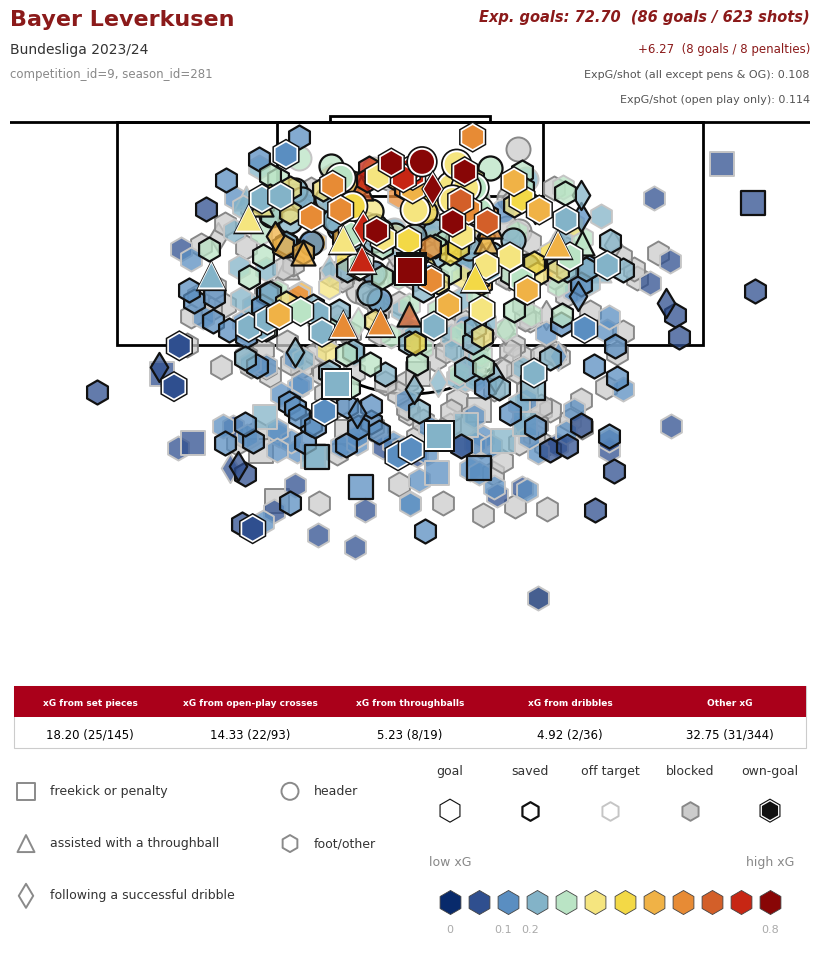

In [9]:
fig = draw_statsbomb_shotmap(
    shots_df=shots,
    events_df=events,
    title=team_name,
    subtitle=competition_name,
    competition=f"competition_id={competition_id}, season_id={season_id}",
)
plt.show()

In [10]:
fig.savefig("bayer_leverkusen_shotmap.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())